## Setup

In [1]:
import os, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightning
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

from mlcolvar.cvs import DeepLDA
from mlcolvar.data import DictDataset, DictModule
from mlcolvar.utils.io import load_dataframe, create_dataset_from_files
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.utils.plot import plot_metrics
from mlcolvar.utils.fes import compute_fes
from mlcolvar.explain.sensitivity import sensitivity_analysis

In [2]:
# Configurations
BASE_DIR   = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR  = BASE_DIR / "input"
SAMPLE_DIR = BASE_DIR / "sample"
GMX_CMD    = "gmx_mpi"
NUM_STEPS  = 10_000   # productions: 500_000
STRIDE     = 100

# ── Reproducibility ───────────────────────────────────────────────────────
torch.manual_seed(42)

os.chdir(BASE_DIR)

In [3]:
# Check working directory
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [4]:
# Helper functions

def clean(folder='./'):
    """Remove GROMACS / PLUMED output files from a simulation folder."""
    subprocess.run("rm -f bck.* COLVAR KERNELS alanine.*", cwd=folder, shell=True)


def execute(command, folder, background=False):
    """Execute a shell command inside *folder* and print its exit status."""
    cmd = subprocess.run(
        command, cwd=folder, shell=True,
        capture_output=True, text=True, close_fds=background
    )
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

In [5]:
# ── Plotting helper functions ─────────────────────────────────────────────
# These are retained from the original notebook with minor style cleanup.

def plot_ramachandran(x, y, z, ax=None):
    """Hexbin Ramachandran plot coloured by the DeepLDA CV value."""
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4), dpi=100)
        ax.set_title('Ramachandran plot')
    h = ax.hexbin(x, y, C=z, cmap='coolwarm')
    cbar = plt.colorbar(h, ax=ax)
    cbar.set_label('Deep-LDA CV')
    ax.set_xlabel(r'$\phi$ [rad]')
    ax.set_ylabel(r'$\psi$ [rad]')


def plot_cv_histogram(s, label=None, ax=None, **kwargs):
    """Histogram of the CV values; accepts both tensors and numpy arrays."""
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4), dpi=100)
        ax.set_title('Histogram')
    # Convert torch.Tensor to numpy if necessary
    if isinstance(s, torch.Tensor):
        s = s.squeeze(1).detach().numpy()
    ax.hist(s, **kwargs)
    if label is not None:
        ax.set_xlabel(label)

## 1.1 DeepLDA CV on pairwise distances (heavy atoms) 

### (a) Train CV

To load the PLUMED output of the two unbiased MD runs we can use the [load_dataframe](https://mlcvs.readthedocs.io/en/latest/autosummary/mlcvs.utils.io.load_dataframe.html) function.
From this data, we build our training dataset. Since this is a supervised learning task, the dataset will be of the form (`X,y`), in which `X` are the input samples and `y` the corresponding labels (the states to which they belong to).

In [ ]:
# ── MIGRATION NOTE ────────────────────────────────────────────────────────
# Old (mlcvs):
#   from mlcvs.utils.io import load_dataframe
#   colvarA = load_dataframe(...)
#   X = torch.Tensor(colvar.filter(regex='d_').values)
#   y = torch.Tensor(colvar['label'].values)
#   dataset = TensorDataset(X, y)
#   train_loader = FastTensorDataLoader(...)
#
# New (mlcolvar):
#   create_dataset_from_files handles all of the above and returns a
#   DictDataset with keys 'data' (features) and 'labels' (class indices).
# ─────────────────────────────────────────────────────────────────────────

n_states = 2  # A (C7eq) and B (C7ax)

filenames = [
    'sample/0_unbiased-sA/COLVAR',
    'sample/0_unbiased-sB/COLVAR',
]

# filter_args selects only columns matching the regex 'd_' (pairwise distances)
dataset, df = create_dataset_from_files(
    filenames,
    return_dataframe=True,
    filter_args={'regex': 'd_'},   # keep only distance descriptors
)

# Inspect the loaded tensors
X      = dataset[:]['data']    # shape: (N, n_features)
labels = dataset[:]['labels']  # shape: (N,)  integer class indices

print(f"Descriptor matrix X      : {X.shape}")
print(f"Class label vector labels: {labels.shape}")
print(f"Dataframe columns        : {list(df.columns[:6])} ...")


Class 0 dataframe shape:  (101, 53)
Class 1 dataframe shape:  (101, 53)

 - Loaded dataframe (202, 53): ['time', 'phi', 'psi', 'theta', 'xi', 'ene', 'd_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_11_16', 'd_11_17', 'd_11_19', 'd_15_16', 'd_15_17', 'd_15_19', 'd_16_17', 'd_16_19', 'd_17_19', 'walker', 'labels']
 - Descriptors (202, 45): ['d_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_

We can take a look at the descriptors, by computing their histogram in the two states. 

--> **Question:** Is there any descriptor that is able to discriminate by its own between the states?

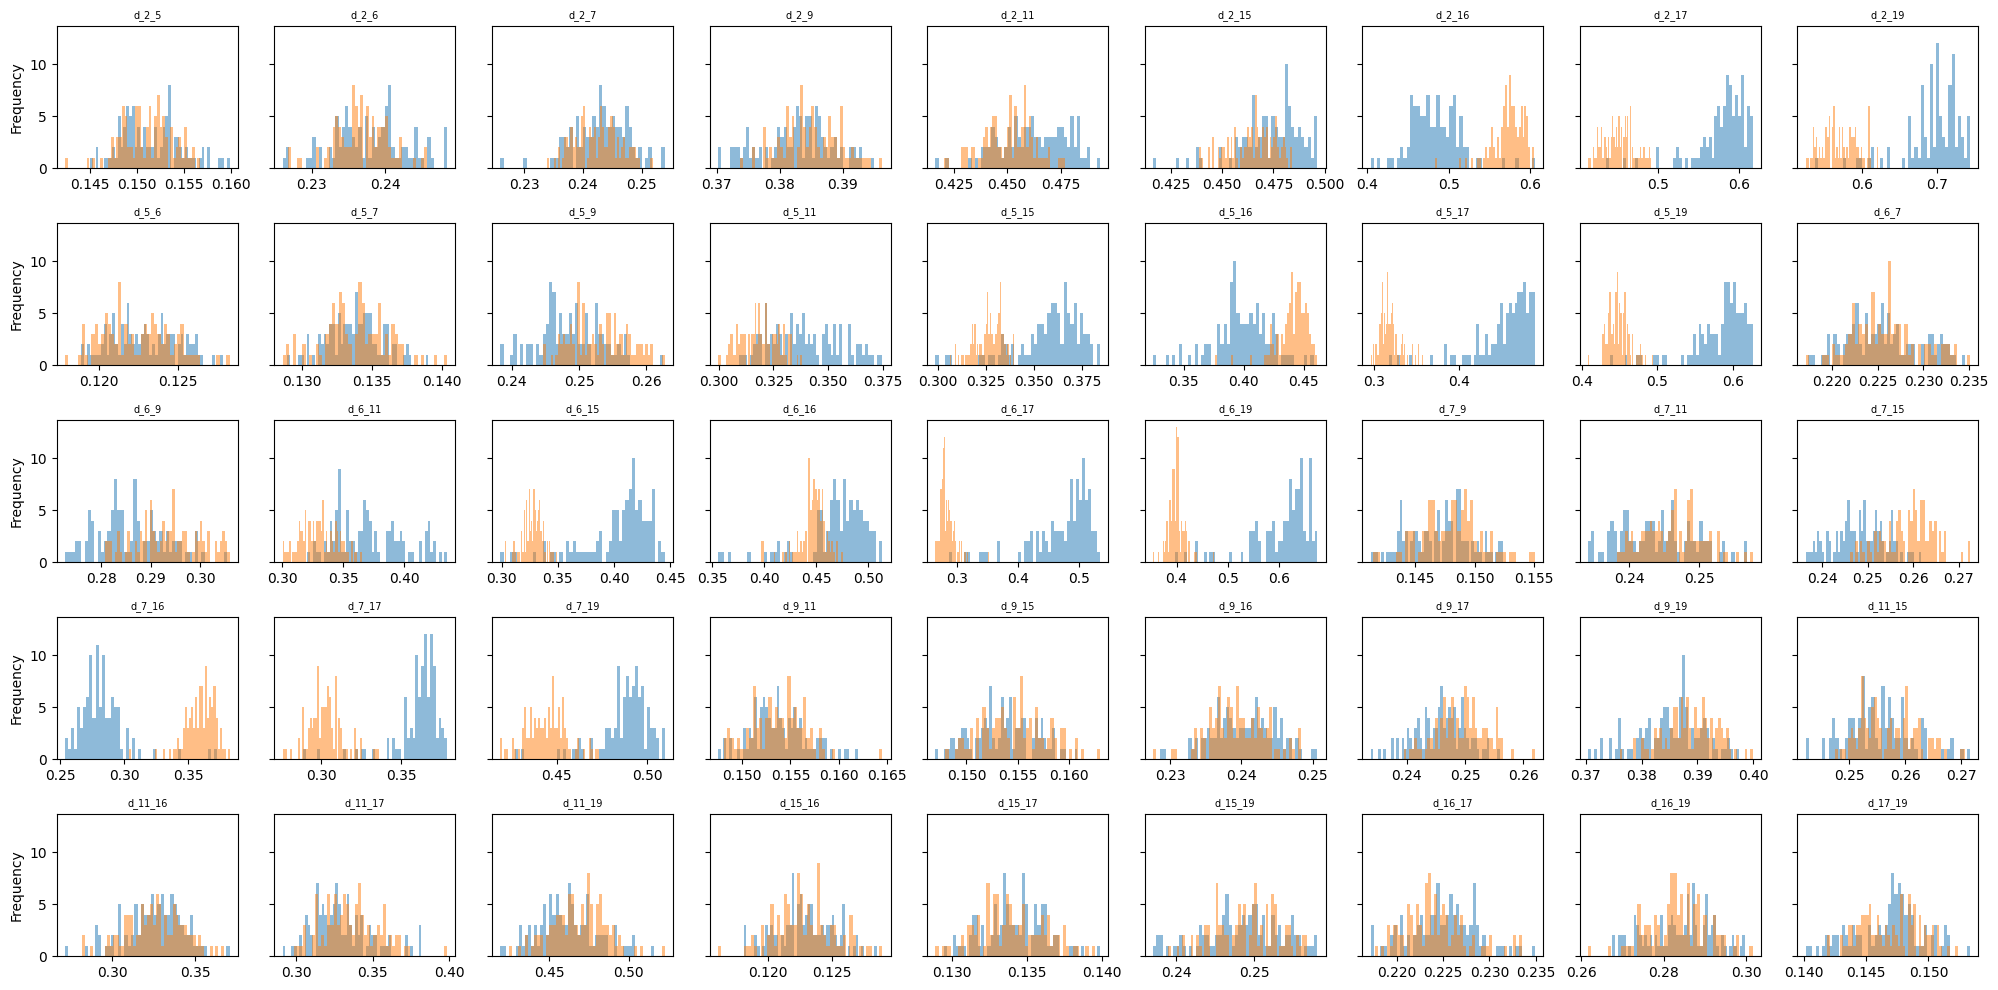

In [7]:
# ── Histogram of each descriptor in states A and B ────────────────────────
# The 'state' column (added by create_dataset_from_files as 'labels') is used
# to split the data; 'labels' == 0 → state A, 'labels' == 1 → state B.

descriptor_cols = [c for c in df.columns if c.startswith('d_')]
n_desc = len(descriptor_cols)

fig, axs = plt.subplots(5, 9, figsize=(20, 10), sharey=True)

for ax, col in zip(axs.flatten(), descriptor_cols):
    df.groupby('labels')[col].plot.hist(bins=50, alpha=0.5, ax=ax, legend=False)
    ax.set_title(col, fontsize=7)

plt.tight_layout()
plt.show()

Here we use the [mlcvs](https://mlcvs.readthedocs.io) package to train a DeepLDA CV out of this data. This can be as simple as follows: define the network architecture, specify when to stop to training (e.g. by using early stopping on validation score) and call the fit method. This will output the training and validation score along the training. Let's give it a try!

In [8]:
# ── Hyperparameters ───────────────────────────────────────────────────────
n_features   = X.shape[1]   # number of input descriptors
nn_layers    = [n_features, 30, 30, 5]  # [input, hidden..., NN output]
activation   = 'tanh'
sw_reg       = 0.05   # β: S_w regularisation (λ in old notation)
# Note: α = 2/β is set automatically inside FisherDiscriminantLoss

nn_options = {'activation': activation}
options    = {'nn': nn_options}          # no 'lda' key needed

model = DeepLDA(nn_layers, n_states=n_states, options=options)

# sw_reg (β) controls S_w' = S_w + β·I;  lorentzian_reg = α = 2/β
# These two are coupled as in Bonati, Rizzi & Parrinello (2020).
model.lorentzian_reg = 2.0 / sw_reg     # = 40 for sw_reg = 0.05

print(model)
print(f"lorentzian_reg (α = 2/β): {model.lorentzian_reg}")

DeepLDA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=45, out_features=45, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=45, out_features=30, bias=True)
      (1): Tanh()
      (2): Linear(in_features=30, out_features=30, bias=True)
      (3): Tanh()
      (4): Linear(in_features=30, out_features=5, bias=True)
    )
  )
  (lda): LDA(in_features=5, out_features=1)
)
lorentzian_reg (α = 2/β): 40.0


However, to better understand what we are doing, we shall consider a more detailed example, in which we analyze the different steps and options. First we create a `TensorDataset` which we then divide into training and validation set. From them, we construct `Dataloader`-like objects. The definition of such auxiliary objects is a standard PyTorch practice, which allows us to easily train the models on different devices.

In [9]:
datamodule = DictModule(dataset, lengths=[0.8, 0.2])
print(datamodule)

{Train dataloader: None}
{Validation dataloader: None}
{Test dataloader: None}
{Predict dataloader: None}


Then, we need to inizialize the neural network and the optimizer and define when to stop the training (EarlyStopping or after a given number of epochs). The following is a list with all the parameters and their explanation. Note that we also standardize the inputs such that their range is betwen the -1 and 1 in the training set. 

| Parameter | Type | Description |
| :- | :- | :- |
| **Neural network** |
| nodes | list | NN architecture (last value equal to the number of hidden layers which are input of LDA) |
| activation | string | Activation function (relu,tanh,elu,linear) |
| **Optimization** |
| lrate | float | Learning rate |
| sw_reg | float | S_w matrix regularization ($\lambda$)| 
| l2_reg | float | L2 regularization |
| num_epochs | int | Number of epochs |
| **Early Stopping** |
| es_patience | int | Number of epochs before stopping |
| es_consecutive | bool | Whether es_patience should count consecutive (True) or cumulative patience |
| es_min_delta | float | Minimum decrease of validation loss |
| **Log** |
| log_every | int | How often print the train/valid loss during training |